# File 09 LR — Lighting-Robust App Inference Demo
Segmentation → crop_masked → CLAHE → diabetes classifier. Not a clinical diagnosis.


In [62]:
import os, json, shutil, time
from pathlib import Path
from datetime import datetime
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_b0
import segmentation_models_pytorch as smp

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## Configuration


In [63]:
# ====== SET YOUR IMAGE PATH ======
IMAGE_PATH=r'WhatsApp Image 2026-05-08 at 8.42.21 PM.jpeg'
# ==================================

SEG_CHECKPOINT=Path(r'D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\05_training_runs\checkpoints\best_efficientnetb0_unet.pth')
CLS_CHECKPOINT=Path(r'D:\DIABETES\diabetes_pipeline_outputs\05_segmented_training_lighting_robust\best_segmented_lighting_robust_model.pth')
THRESHOLD_JSON=Path(r'D:\DIABETES\diabetes_pipeline_outputs\05_segmented_training_lighting_robust\05_lr_best_checkpoint_summary.json')
OUTPUT_DIR=Path(r'D:\DIABETES\diabetes_pipeline_outputs\09_app_inference_lighting_robust_outputs')
SEG_SIZE=384; CLS_SIZE=224; SEG_THRESHOLD=0.5
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
print(f'Image: {IMAGE_PATH}')


Image: WhatsApp Image 2026-05-08 at 8.42.21 PM.jpeg


## Helper Functions


In [64]:
def correct_lighting_clahe(image_pil, clip_limit=1.5, tile_grid_size=(8,8)):
    img_rgb=np.array(image_pil.convert('RGB'))
    lab=cv2.cvtColor(img_rgb,cv2.COLOR_RGB2LAB)
    l,a,b=cv2.split(lab)
    clahe=cv2.createCLAHE(clipLimit=clip_limit,tileGridSize=tile_grid_size)
    l_eq=clahe.apply(l)
    return Image.fromarray(cv2.cvtColor(cv2.merge([l_eq,a,b]),cv2.COLOR_LAB2RGB))

def pad_square(img):
    w,h=img.size; s=max(w,h); new=Image.new('RGB',(s,s),(0,0,0)); new.paste(img,((s-w)//2,(s-h)//2)); return new

def keep_largest_component(mask):
    labeled,num=ndimage.label(mask)
    if num<=1: return mask
    sizes=ndimage.sum(mask,labeled,range(1,num+1))
    return (labeled==np.argmax(sizes)+1).astype(np.uint8)

def create_crop_masked(img_rgb, mask):
    bb=img_rgb*mask[:,:,np.newaxis]
    rows=np.any(mask,axis=1); cols=np.any(mask,axis=0)
    if not rows.any() or not cols.any(): return bb,(0,img_rgb.shape[0],0,img_rgb.shape[1])
    y1,y2=np.where(rows)[0][[0,-1]]; x1,x2=np.where(cols)[0][[0,-1]]
    y2+=1; x2+=1
    return bb[y1:y2,x1:x2].copy(),(int(y1),int(y2),int(x1),int(x2))

print('Helpers defined.')


Helpers defined.


## Load Models and Threshold


In [65]:
def load_seg_model(path, device):
    model=smp.Unet(encoder_name='efficientnet-b0',encoder_weights=None,in_channels=3,classes=1,activation=None)
    ckpt=torch.load(path,map_location=device)
    sd=ckpt.get('model_state_dict',ckpt.get('state_dict',ckpt))
    model.load_state_dict(sd); model.to(device); model.eval(); return model

def load_cls_model(path, device):
    model=efficientnet_b0(weights=None)
    model.classifier=nn.Sequential(nn.Dropout(0.3),nn.Linear(model.classifier[1].in_features,1))
    ckpt=torch.load(path,map_location=device)
    sd=ckpt.get('model_state_dict',ckpt.get('state_dict',ckpt))
    model.load_state_dict(sd); model.to(device); model.eval(); return model

def load_threshold(path, fallback=0.45):
    if not Path(path).exists(): print(f'WARNING: fallback {fallback}'); return fallback
    with open(path) as f: data=json.load(f)
    for k in ['best_threshold','selected_threshold','selected_validation_threshold']:
        if k in data: return float(data[k])
    print(f'WARNING: fallback {fallback}'); return fallback

seg_model=load_seg_model(SEG_CHECKPOINT,DEVICE)
cls_model=load_cls_model(CLS_CHECKPOINT,DEVICE)
threshold=load_threshold(THRESHOLD_JSON)
print(f'Models loaded. Threshold: {threshold:.3f}')


Models loaded. Threshold: 0.500


## Inference Functions


In [66]:
seg_transform=T.Compose([T.Lambda(pad_square),T.Resize((SEG_SIZE,SEG_SIZE)),T.ToTensor(),T.Normalize(mean=MEAN,std=STD)])
cls_transform=T.Compose([T.Lambda(correct_lighting_clahe),T.Lambda(pad_square),T.Resize((CLS_SIZE,CLS_SIZE)),T.ToTensor(),T.Normalize(mean=MEAN,std=STD)])

def predict_tongue_mask(img_pil):
    w,h=img_pil.size; inp=seg_transform(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): prob=torch.sigmoid(seg_model(inp)).cpu().numpy()[0,0]
    mask=(prob>SEG_THRESHOLD).astype(np.uint8)
    mask=cv2.resize(mask,(w,h),interpolation=cv2.INTER_NEAREST)
    return keep_largest_component(mask)

def compute_qc(mask,bbox,shape):
    h,w=shape[:2]; fg=int(mask.sum()); fg_r=fg/(h*w)
    y1,y2,x1,x2=bbox; bw,bh=x2-x1,y2-y1; bar=(bw*bh)/(h*w)
    tt,tb,tl,tr=(y1==0),(y2==h),(x1==0),(x2==w)
    ec=sum([tt,tb,tl,tr])
    return {'mask_foreground_pixels':fg,'mask_foreground_ratio':round(fg_r,6),'bbox_area_ratio':round(bar,6),'edge_count':ec,'failed_no_mask':fg==0,'suspicious_small_mask':fg_r<0.02 and fg>0,'suspicious_large_mask':fg_r>0.85,'suspicious_tiny_bbox':bar<0.02 and fg>0,'suspicious_edge_touch':ec>=3}

def assess_retake(qc):
    if qc['failed_no_mask']: return True,False,'failed','Please retake: no tongue mask detected.'
    if qc['suspicious_small_mask'] or qc['suspicious_tiny_bbox']: return True,False,'suspicious_small','Please retake: tongue not visible enough.'
    if qc['suspicious_large_mask']: return False,True,'suspicious_large','Prediction generated; large mask — review recommended.'
    if qc['suspicious_edge_touch']: return False,False,'edge_touch','Prediction generated; mask touches image edges — review recommended.'
    return False,False,'ok','Image accepted.'

def get_risk_band(prob, sel_thr):
    if prob<0.20: return 'Low image-based risk'
    if prob<sel_thr: return 'Borderline / uncertain'
    if prob<0.70: return 'Elevated image-based risk'
    return 'High image-based risk'

print('Inference functions defined.')


Inference functions defined.


## Full Pipeline


In [67]:
def run_full_demo_inference(image_path, save_outputs=True, output_dir=None):
    ip=Path(image_path); assert ip.exists(), f'Not found: {ip}'
    img_pil=Image.open(ip).convert('RGB'); img_rgb=np.array(img_pil)
    mask=predict_tongue_mask(img_pil)
    black_bg=img_rgb*mask[:,:,np.newaxis]
    crop_m,bbox=create_crop_masked(img_rgb,mask)
    qc=compute_qc(mask,bbox,img_rgb.shape)
    ret_req,ret_rec,seg_status,message=assess_retake(qc)
    crop_m_pil=Image.fromarray(crop_m)
    crop_m_clahe=correct_lighting_clahe(crop_m_pil)
    if not ret_req:
        inp=cls_transform(crop_m_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): logit=cls_model(inp)
        prob=float(torch.sigmoid(logit).item())
        pred_cls='diabetes' if prob>=threshold else 'non_diabetes'
        risk_band=get_risk_band(prob,threshold)
    else:
        logit=None; prob=None; pred_cls=None; risk_band=None
    saved={}
    if save_outputs:
        od=Path(output_dir or output_dir) if output_dir else OUTPUT_DIR
        ts=datetime.now().strftime('%Y%m%d_%H%M%S')
        rd=od/f'{ip.stem}_{ts}'; rd.mkdir(parents=True,exist_ok=True)
        shutil.copy2(ip,rd/f'original{ip.suffix}')
        cv2.imwrite(str(rd/'mask.png'),mask*255)
        cv2.imwrite(str(rd/'black_background.png'),cv2.cvtColor(black_bg,cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(rd/'crop_masked.png'),cv2.cvtColor(crop_m,cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(rd/'crop_masked_clahe.png'),cv2.cvtColor(np.array(crop_m_clahe),cv2.COLOR_RGB2BGR))
        saved={'mask_path':str(rd/'mask.png'),'crop_masked_path':str(rd/'crop_masked.png'),'clahe_crop_path':str(rd/'crop_masked_clahe.png'),'run_dir':str(rd)}
        result={'input_image_path':str(ip),'probability_diabetes':prob,'predicted_class':pred_cls,'threshold':threshold,'risk_band':risk_band,'retake_required':ret_req,'retake_recommended':ret_rec,'segmentation_status':seg_status,'mask_foreground_ratio':qc['mask_foreground_ratio'],'bbox_area_ratio':qc['bbox_area_ratio'],'message':message,**saved}
        json.dump(result,open(rd/'result_summary.json','w'),indent=2,default=str)
        with open(rd/'result_summary.txt','w') as f:
            for k,v in result.items(): f.write(f'{k}: {v}\n')
    else:
        result={'input_image_path':str(ip),'probability_diabetes':prob,'predicted_class':pred_cls,'threshold':threshold,'risk_band':risk_band,'retake_required':ret_req,'retake_recommended':ret_rec,'segmentation_status':seg_status,'mask_foreground_ratio':qc['mask_foreground_ratio'],'bbox_area_ratio':qc['bbox_area_ratio'],'message':message}
    return result,{'original':img_rgb,'mask':mask,'black_bg':black_bg,'crop_masked':crop_m,'crop_masked_clahe':np.array(crop_m_clahe)}

print('Full pipeline defined.')


Full pipeline defined.


## Run and Display


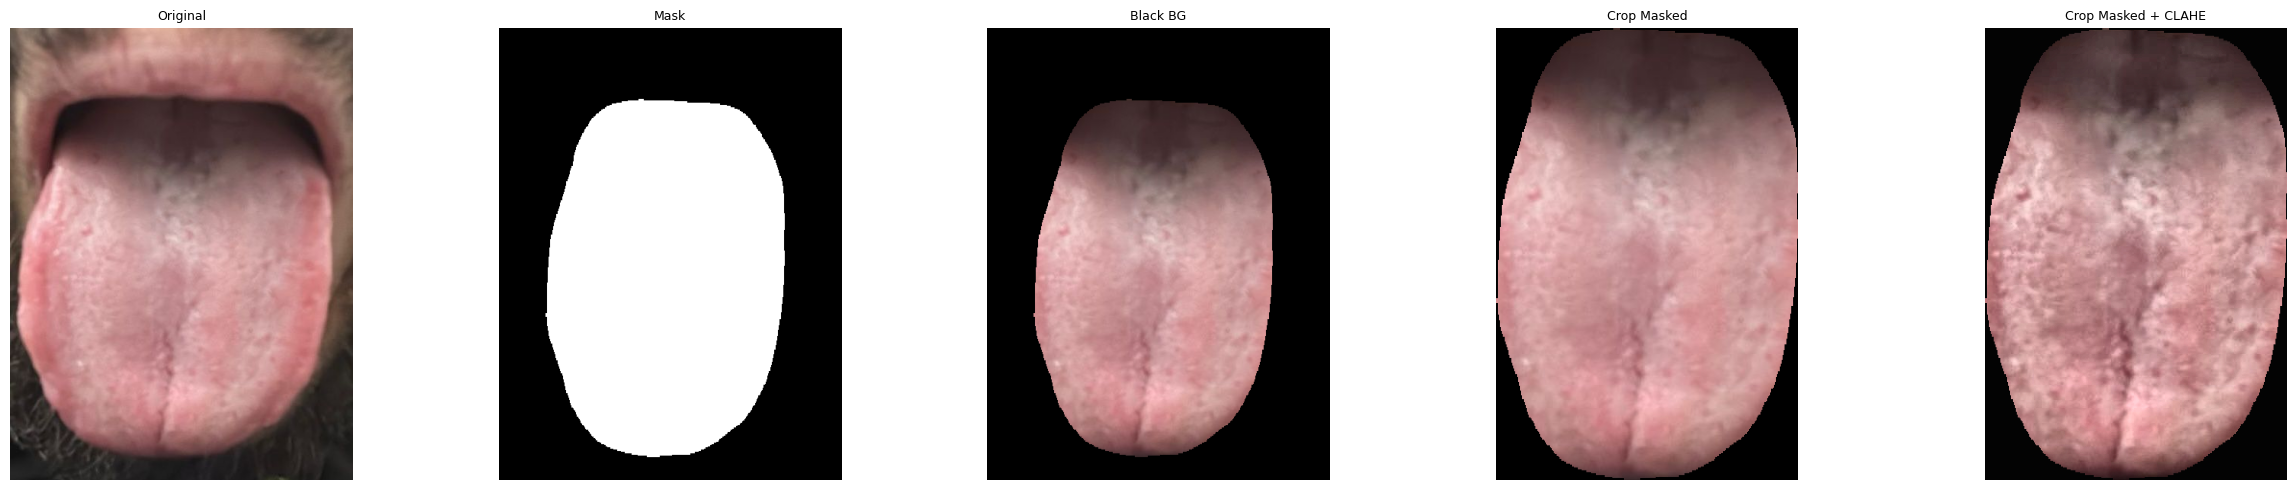

In [68]:
result, images = run_full_demo_inference(IMAGE_PATH)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
titles = ['Original', 'Mask', 'Black BG', 'Crop Masked', 'Crop Masked + CLAHE']
imgs = [images['original'], images['mask'], images['black_bg'], images['crop_masked'], images['crop_masked_clahe']]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


Generating Grad-CAM explainability map...


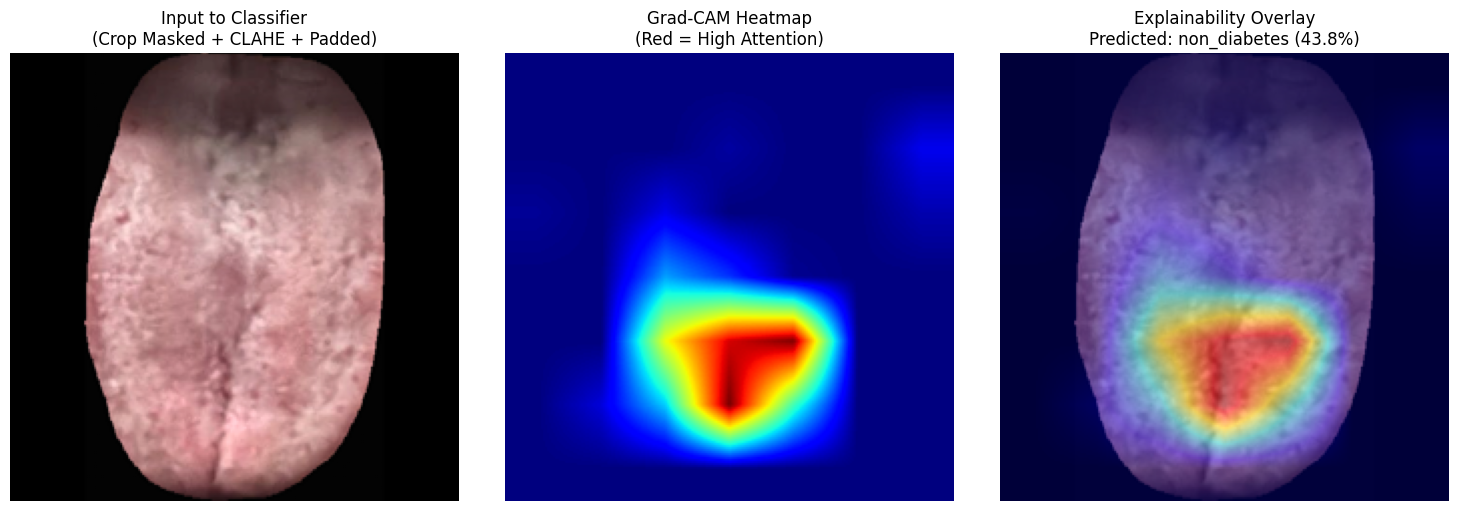

In [69]:
# ==============================================================
# GRAD-CAM EXPLAINABILITY FOR INFERENCE DEMO
# ==============================================================

# 1. Ensure the prediction was valid (not rejected by segmentation QC)
if result.get('probability_diabetes') is not None:
    
    print("Generating Grad-CAM explainability map...")
    
    # Target the last convolutional layer of EfficientNet-B0
    TARGET_LAYER = cls_model.features[-1]
    
    def generate_app_gradcam(crop_m_array, target_diabetes=True):
        # Convert the numpy array output of the inference loop back to PIL
        crop_m_pil = Image.fromarray(crop_m_array)
        
        cls_model.eval()
        activations = {}
        gradients = {}

        def forward_hook(module, input, output):
            activations["value"] = output

        def backward_hook(module, grad_input, grad_output):
            gradients["value"] = grad_output[0]

        forward_handle = TARGET_LAYER.register_forward_hook(forward_hook)
        backward_handle = TARGET_LAYER.register_full_backward_hook(backward_hook)

        try:
            # 1. Prepare visual overlay image (CLAHE -> Pad -> Resize)
            # This matches exactly what the model "sees"
            img_display = correct_lighting_clahe(crop_m_pil)
            img_display = pad_square(img_display)
            img_display = img_display.resize((CLS_SIZE, CLS_SIZE))
            img_rgb = np.array(img_display).astype(np.float32) / 255.0

            # 2. Prepare actual model tensor input
            inp = cls_transform(crop_m_pil).unsqueeze(0).to(DEVICE)

            cls_model.zero_grad(set_to_none=True)
            out = cls_model(inp)
            logit = out.reshape(-1)[0]
            
            # Target the diabetes class (positive logit = diabetes evidence)
            target = logit if target_diabetes else -logit
            target.backward()

            if "value" not in activations or "value" not in gradients:
                raise RuntimeError("Grad-CAM hooks failed.")

            acts = activations["value"].detach()
            grads = gradients["value"].detach()

            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam_map = (weights * acts).sum(dim=1, keepdim=True)
            cam_map = torch.relu(cam_map)

            heatmap = cam_map.squeeze().detach().cpu().numpy()
            if heatmap.max() > heatmap.min():
                heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
            else:
                heatmap = np.zeros_like(heatmap)

            heatmap = cv2.resize(heatmap, (CLS_SIZE, CLS_SIZE), interpolation=cv2.INTER_LINEAR)
            heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
            heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            overlay = (0.55 * img_rgb + 0.45 * heatmap_colored)
            overlay = np.clip(overlay, 0, 1)

            return img_rgb, heatmap, overlay

        finally:
            forward_handle.remove()
            backward_handle.remove()

    # Generate the map targeting "diabetes" evidence
    img_rgb, heatmap, overlay = generate_app_gradcam(images['crop_masked'], target_diabetes=True)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Input to Classifier\n(Crop Masked + CLAHE + Padded)')
    axes[0].axis('off')
    
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap\n(Red = High Attention)')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f'Explainability Overlay\nPredicted: {result["predicted_class"]} ({result["probability_diabetes"]:.1%})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Cannot generate Grad-CAM because the image failed segmentation quality checks and was rejected.")

In [70]:
print('='*60)
print('LIGHTING-ROBUST INFERENCE RESULT')
print('='*60)
for k, v in result.items(): print(f'  {k}: {v}')
print('='*60)
print(f'\n>>> {result["message"]}')
if result.get('probability_diabetes') is not None:
    print(f'>>> Diabetes probability : {result["probability_diabetes"]:.4f}')
    print(f'>>> Predicted class      : {result["predicted_class"]}')
    print(f'>>> Risk band            : {result["risk_band"]}')
    print(f'>>> Threshold used       : {result["threshold"]:.3f}')
else:
    print('>>> Prediction not generated (retake required).')
print()
print('DISCLAIMER: This is NOT a diagnosis.')
print('This is an image-based screening/risk-estimation prototype.')
print('Consult a physician for any health concerns.')


LIGHTING-ROBUST INFERENCE RESULT
  input_image_path: WhatsApp Image 2026-05-08 at 8.42.21 PM.jpeg
  probability_diabetes: 0.4383792579174042
  predicted_class: non_diabetes
  threshold: 0.5
  risk_band: Borderline / uncertain
  retake_required: False
  retake_recommended: False
  segmentation_status: ok
  mask_foreground_ratio: 0.46066
  bbox_area_ratio: 0.553045
  message: Image accepted.
  mask_path: D:\DIABETES\diabetes_pipeline_outputs\09_app_inference_lighting_robust_outputs\WhatsApp Image 2026-05-08 at 8.42.21 PM_20260513_054630\mask.png
  crop_masked_path: D:\DIABETES\diabetes_pipeline_outputs\09_app_inference_lighting_robust_outputs\WhatsApp Image 2026-05-08 at 8.42.21 PM_20260513_054630\crop_masked.png
  clahe_crop_path: D:\DIABETES\diabetes_pipeline_outputs\09_app_inference_lighting_robust_outputs\WhatsApp Image 2026-05-08 at 8.42.21 PM_20260513_054630\crop_masked_clahe.png
  run_dir: D:\DIABETES\diabetes_pipeline_outputs\09_app_inference_lighting_robust_outputs\WhatsApp Imag